E-Commerce Sales Analysis

In [75]:
import pandas as pd


Load Dataset

In [76]:
df=pd.read_csv('sales.csv')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2015 entries, 0 to 2014
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Order_ID  2015 non-null   int64  
 1   Date      2015 non-null   object 
 2   Customer  2005 non-null   object 
 3   Category  2010 non-null   object 
 4   Product   2015 non-null   object 
 5   Quantity  2015 non-null   int64  
 6   Price     2005 non-null   float64
 7   Region    2005 non-null   object 
 8   Revenue   2005 non-null   float64
dtypes: float64(2), int64(2), object(5)
memory usage: 141.8+ KB


Data Overview

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2015 entries, 0 to 2014
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Order_ID  2015 non-null   int64  
 1   Date      2015 non-null   object 
 2   Customer  2005 non-null   object 
 3   Category  2010 non-null   object 
 4   Product   2015 non-null   object 
 5   Quantity  2015 non-null   int64  
 6   Price     2005 non-null   float64
 7   Region    2005 non-null   object 
 8   Revenue   2005 non-null   float64
dtypes: float64(2), int64(2), object(5)
memory usage: 141.8+ KB


In [3]:
df.shape

(2015, 9)

In [4]:
df.describe()

,Order_ID,Quantity,Price,Revenue
count,2015.000000,2015.000000,2005.000000,2005.000000
mean,11002.740943,1.989578,7408.479900,14036.100539
std,578.219238,1.131121,9141.054448,21002.972249
min,10001.000000,1.000000,154.430000,192.040000
25%,10502.500000,1.000000,1413.440000,2386.240000
50%,11003.000000,2.000000,3569.220000,6066.300000
75%,11504.500000,3.000000,9518.700000,16809.520000
max,12000.000000,5.000000,44932.990000,197214.600000


In [5]:
df.isna().sum()

,0
Order_ID,0
Date,0
Customer,10
Category,5
Product,0
Quantity,0
Price,10
Region,10
Revenue,10


In [6]:
df[df.isnull().any(axis=1)]

,Order_ID,Date,Customer,Category,Product,Quantity,Price,Region,Revenue
13,11619,2025-08-19,Laila,Accessories,Mouse,4,1398.35,NaN,5593.40
28,10545,2025-09-09,NaN,Home,Office Chair,2,2776.05,Giza,5552.10
236,10101,2025-10-29,Nour,Electronics,Laptop,2,20363.81,NaN,40727.62
277,11250,2025-02-09,Karim,Home,Air Purifier,2,4456.89,NaN,8913.78
297,11053,2025-05-06,NaN,Gaming,Gaming Keyboard,1,4455.66,Tanta,4455.66
324,11977,2025-06-19,NaN,Electronics,Laptop,1,24021.27,Giza,24021.27
333,11735,2025-05-26,Khaled,Electronics,Laptop,3,NaN,Cairo,NaN
372,10323,2025-07-08,Menna,Home,Air Purifier,1,7725.21,NaN,7725.21
466,10377,2025-05-17,Mostafa,Gaming,Gaming Chair,1,10977.16,NaN,10977.16
469,10440,2025-10-30,Mariam,Electronics,Monitor,5,NaN,Cairo,NaN


In [7]:
df.duplicated().sum()

np.int64(15)

Data Cleaning

In [8]:
df=df.drop_duplicates()

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df['Customer']=df['Customer'].fillna('Unknow')

In [11]:
df[df["Category"].isnull()]

,Order_ID,Date,Customer,Category,Product,Quantity,Price,Region,Revenue
591,10310,2025-09-16,Sara,NaN,Laptop,2,20905.58,Qalyubia,41811.16
1080,11849,2025-12-06,Nada,NaN,Game Controller,4,2786.09,Mansoura,11144.36
1160,10919,2025-01-18,Menna,NaN,Desk Lamp,4,492.89,Suez,1971.56
1392,11099,2025-12-17,Farah,NaN,Air Purifier,3,2921.22,Suez,8763.66
1999,11397,2025-08-02,Ahmed,NaN,USB Hub,3,717.74,Mansoura,2153.22


In [12]:
product_category=df.dropna(subset=['Category']).drop_duplicates('Product').set_index('Product')['Category']
df['Category']=df['Category'].fillna(df['Product'].map(product_category))

In [13]:
df[df['Price'].isna()][["Product", "Price"]]

,Product,Price
333,Laptop,NaN
469,Monitor,NaN
659,Gaming Headset,NaN
878,Smartphone,NaN
1214,Air Purifier,NaN
1453,Phone Stand,NaN
1574,Phone Stand,NaN
1722,Desk Lamp,NaN
1860,Desk Lamp,NaN
1896,Laptop,NaN


In [14]:
product_avg_price=df.groupby('Product')['Price'].transform('mean')


In [15]:
df['Price']=df['Price'].fillna(product_avg_price)

In [16]:
df["Revenue"]=df['Price']*df['Quantity']

In [17]:
df['Region']=df['Region'].fillna('Unknow')

In [18]:
df['Date']=pd.to_datetime(df['Date'])

In [19]:
df.isna().sum()

,0
Order_ID,0
Date,0
Customer,0
Category,0
Product,0
Quantity,0
Price,0
Region,0
Revenue,0


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2000 entries, 0 to 2014
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Order_ID  2000 non-null   int64         
 1   Date      2000 non-null   datetime64[ns]
 2   Customer  2000 non-null   object        
 3   Category  2000 non-null   object        
 4   Product   2000 non-null   object        
 5   Quantity  2000 non-null   int64         
 6   Price     2000 non-null   float64       
 7   Region    2000 non-null   object        
 8   Revenue   2000 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 156.2+ KB


EDA

In [78]:
total_revenue=round(df['Revenue'].sum(),3)
print(total_revenue)

28142381.58


In [73]:
top_5_Product_Revenue=df.groupby('Product')['Revenue'].sum().sort_values(ascending=False).head(5)
print(top_5_Product_Revenue)

Product
Laptop          8.863631e+06
Smartphone      4.276665e+06
Tablet          3.916402e+06
Monitor         2.799937e+06
Gaming Chair    1.531733e+06
Name: Revenue, dtype: float64


In [72]:
Best_Product=top_5_Product_Revenue.head(1)
print(Best_Product)

Product
Laptop    8.863631e+06
Name: Revenue, dtype: float64


<Axes: xlabel='Product'>

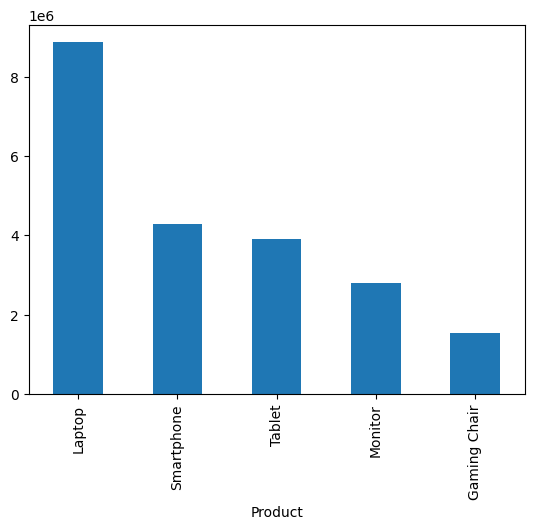

In [23]:
top_5_Product_Revenue.plot(kind="bar")

In [24]:
top_5_Category_Revenue=df.groupby('Category')['Revenue'].sum().sort_values(ascending=False).head(4)
print(top_5_Category_Revenue)

Category
Electronics    2.088335e+07
Gaming         3.246098e+06
Home           2.850096e+06
Accessories    1.130779e+06
Name: Revenue, dtype: float64


In [58]:
Best_Category=top_5_Category_Revenue.head(1)
print(Best_Category)

Category
Electronics    2.088335e+07
Name: Revenue, dtype: float64


<Axes: xlabel='Category'>

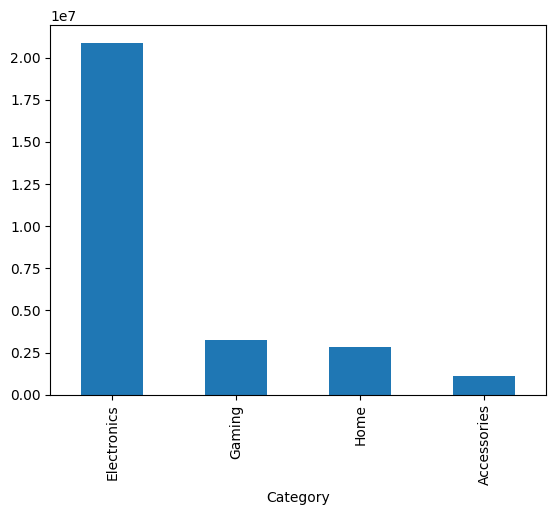

In [25]:
top_5_Category_Revenue.plot(kind="bar")

In [41]:
month_Revenue=df.groupby(df['Date'].dt.month)['Revenue'].sum().sort_index()
print(month_Revenue)

Date
1     2.279341e+06
2     2.110229e+06
3     2.312167e+06
4     2.364149e+06
5     2.117683e+06
6     1.915333e+06
7     2.435131e+06
8     2.373211e+06
9     2.935382e+06
10    2.178442e+06
11    2.916548e+06
12    2.172704e+06
Name: Revenue, dtype: float64


In [59]:
Best_Month=month_Revenue.head(1)
print(Best_Month)

Date
1    2279341.05
Name: Revenue, dtype: float64


<Axes: xlabel='Date'>

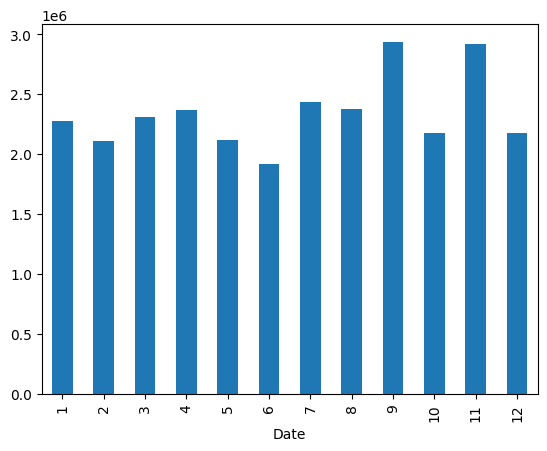

In [38]:
month_Revenue.plot(kind='bar')

In [40]:
top_month_Revenue=month_Revenue.sort_values(ascending=False).head(1)
print(top_month_Revenue)

Date
9    2.935382e+06
Name: Revenue, dtype: float64


In [64]:
Best_Regions=df.groupby('Region')['Revenue'].sum().sort_values(ascending=False)
print(Best_Regions)

Region
Cairo         6.328516e+06
Giza          4.804595e+06
Alexandria    3.967908e+06
Qalyubia      3.047793e+06
Mansoura      3.032558e+06
Tanta         2.555351e+06
Ismailia      2.144675e+06
Suez          2.042222e+06
Unknow        1.867015e+05
Name: Revenue, dtype: float64


<Axes: xlabel='Region'>

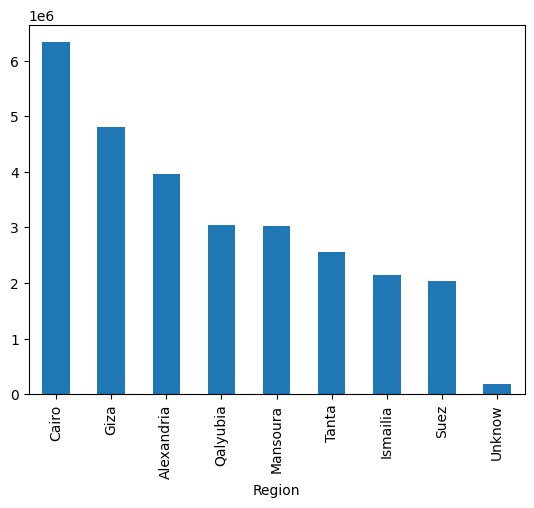

In [65]:
Best_Regions.plot(kind='bar')

In [67]:
Best_Region=Best_Regions.head(1)
print(Best_Region)

Region
Cairo    6.328516e+06
Name: Revenue, dtype: float64


In [48]:
Average_Order_Value=df.groupby('Region')['Revenue'].mean().sort_values(ascending=False)
print(Average_Order_Value)

Region
Unknow        18670.147000
Suez          16080.484252
Giza          14783.368074
Ismailia      14589.623129
Tanta         13963.666388
Mansoura      13910.815617
Qalyubia      13728.799324
Cairo         13727.801290
Alexandria    12924.783317
Name: Revenue, dtype: float64


In [49]:
top_5_Customer_Revenue=df.groupby('Customer')['Revenue'].sum().sort_values(ascending=False).head(5)
print(top_5_Customer_Revenue)

Customer
Laila      2.080719e+06
Adam       1.847384e+06
Mostafa    1.730998e+06
Ahmed      1.582797e+06
Mariam     1.548212e+06
Name: Revenue, dtype: float64


In [61]:
Best_Customer=top_5_Customer_Revenue.head(1)
print(Best_Customer)

Customer
Laila    2.080719e+06
Name: Revenue, dtype: float64


<Axes: xlabel='Customer'>

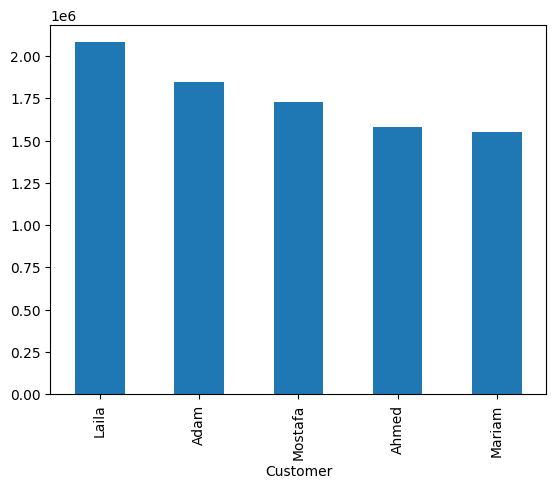

In [50]:
top_5_Customer_Revenue.plot(kind='bar')

In [54]:
top_5_Products_Quantity=df.groupby('Product')['Quantity'].sum().sort_values(ascending=False).head(5)
print(top_5_Products_Quantity)

Product
Tablet        295
Laptop        288
Headphones    286
Monitor       255
Smartphone    230
Name: Quantity, dtype: int64


<Axes: xlabel='Product'>

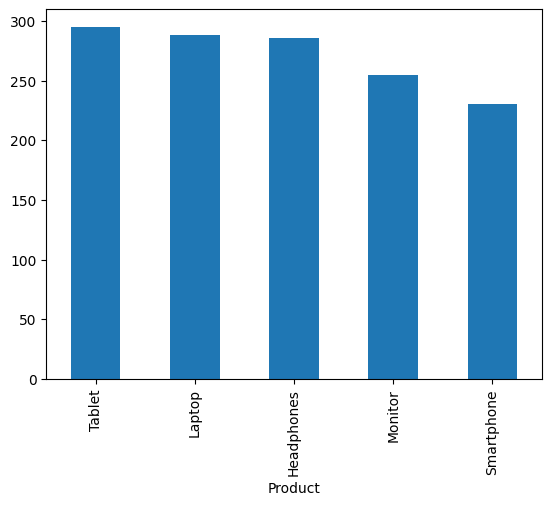

In [55]:
top_5_Products_Quantity.plot(kind='bar')

 Business Insights

- Laptop generated the highest revenue among all products.
- Tablet had the highest number of units sold.
- Electronics generated the highest total revenue among categories.
- Cairo generated the highest total revenue among regions.
- Laila was the highest-revenue customer.
- The highest monthly revenue occurred in January.
- The product with the highest sales volume was not necessarily the product with the highest revenue.

Conclusion

This project analyzed e-commerce sales data using Python and Pandas.

The analysis covered data cleaning, revenue analysis, product performance,
category performance, monthly sales, regional performance, customer analysis,
and sales quantity.

The results show that revenue performance is influenced not only by the
number of units sold, but also by product prices and purchasing behavior.